<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1829 | Val: 446 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 8 (effective batch size ≈ 128, tuned value = 128)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 8 micro-batches per optimizer step (effective batch size ≈ micro_batch x 8).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.65e-05 | train loss 1.2233 acc 0.565 | val loss 0.9101 acc 0.709 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.65e-05 | train loss 0.6944 acc 0.730 | val loss 0.4916 acc 0.821 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.65e-05 | train loss 0.4797 acc 0.795 | val loss 0.4408 acc 0.839 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.65e-05 | train loss 0.4172 acc 0.835 | val loss 0.4382 acc 0.841 *


...

[ConvNeXt-Tiny] Epoch  16/100 | LR: 5.65e-05 | train loss 0.0993 acc 0.957 | val loss 0.3363 acc 0.879


[ConvNeXt-Tiny] Epoch  17/100 | LR: 5.65e-05 | train loss 0.1038 acc 0.956 | val loss 0.3373 acc 0.868


[ConvNeXt-Tiny] Epoch  18/100 | LR: 5.65e-05 | train loss 0.0766 acc 0.969 | val loss 0.4152 acc 0.857


[ConvNeXt-Tiny] Epoch  19/100 | LR: 5.65e-05 | train loss 0.0723 acc 0.968 | val loss 0.3767 acc 0.870


[ConvNeXt-Tiny] Epoch  20/100 | LR: 5.65e-05 | train loss 0.0561 acc 0.975 | val loss 0.3507 acc 0.874

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 20.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.2968)


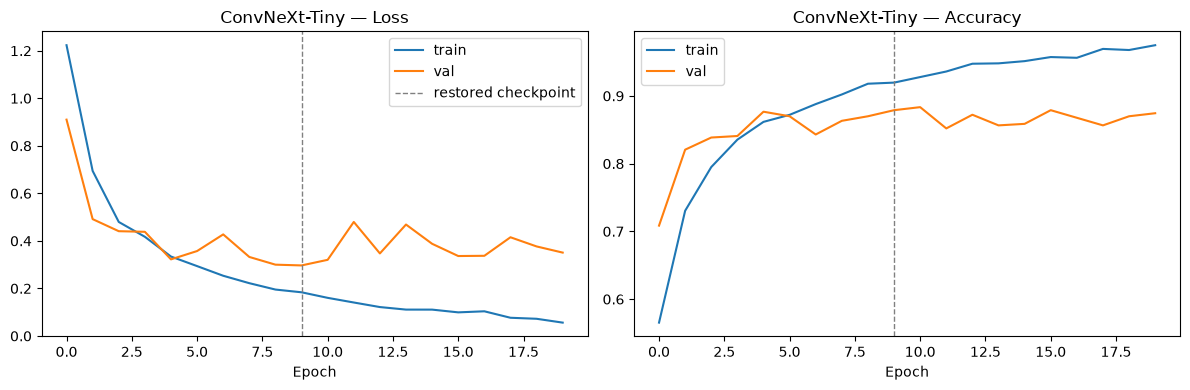

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.798


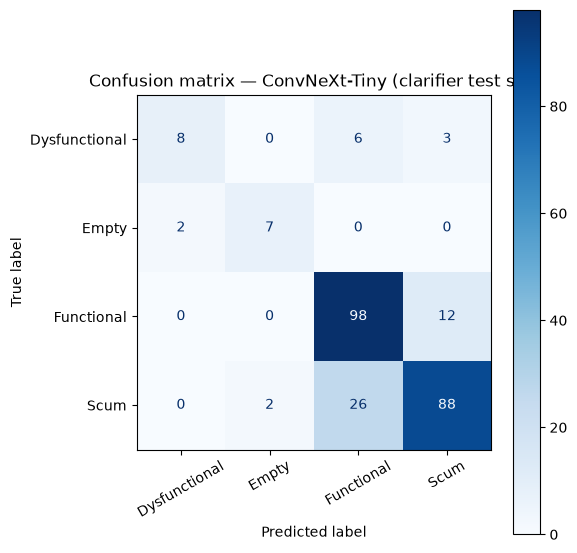

               precision    recall  f1-score   support

Dysfunctional      0.800     0.471     0.593        17
        Empty      0.778     0.778     0.778         9
   Functional      0.754     0.891     0.817       110
         Scum      0.854     0.759     0.804       116

     accuracy                          0.798       252
    macro avg      0.796     0.724     0.748       252
 weighted avg      0.804     0.798     0.794       252



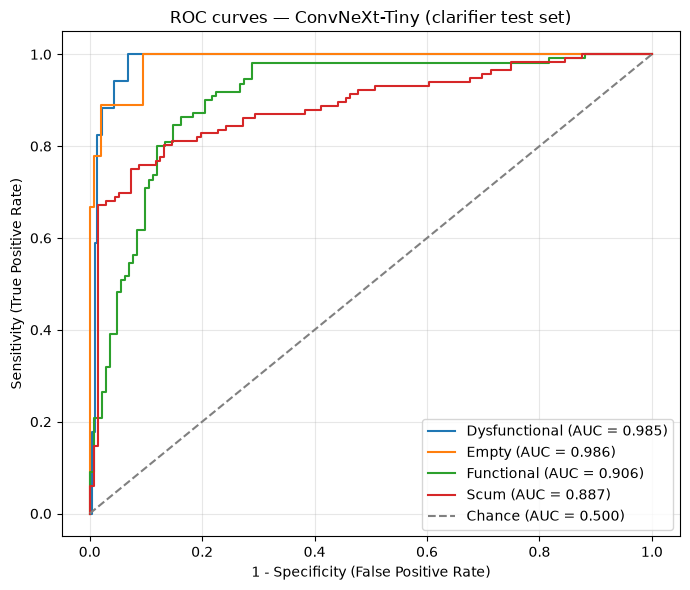

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.985
  Empty          : 0.986
  Functional     : 0.906
  Scum           : 0.887

Mean AUC (over 4/4 classes with test examples): 0.941


(np.float64(0.7976190476190477),
 {'Dysfunctional': 0.9849812265331664,
  'Empty': 0.9862825788751715,
  'Functional': 0.9057618437900127,
  'Scum': 0.8865365111561866})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/clarifier_aug/results_clarifier_convnext_tiny_Fisantekraal.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
